# Sales Forecasting & Demand Intelligence System

**Project by:** Shreyas Yarabadi

This notebook covers an end-to-end sales forecasting pipeline using the Superstore Sales Dataset. We will go through data loading, time series analysis, forecasting with 3 diffrent models, anomaly detection, and product demand segmentation.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Task 1 — Data Loading, Merging & Deep Exploration

### Step 1: Loading the dataset

We use a condtional download approach so that we don't re-download the file every time.

**How it works:**
1. The script checks if `train.csv` already exsits in the current directory.
2. If found, it skips the download.
3. If not found, it uses `kagglehub` to fetch the Superstore Sales Dataset from Kaggle.

In [60]:
import os, shutil

file_name = 'train.csv'

os.makedirs('charts', exist_ok=True)

if not os.path.exists(file_name):
    import kagglehub
    print("File not found locally. Downloading dataset...")
    path = kagglehub.dataset_download("rohitsahoo/sales-forecasting")
    shutil.copy(os.path.join(path, file_name), '.')

    try:
        shutil.rmtree(path)
    except OSError:
        pass

    print("Download complete.")
else:
    print(f"'{file_name}' already exists. Skipping download.")

df = pd.read_csv(file_name)
display(df.head())

'train.csv' already exists. Skipping download.


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


### Step 2: Parsing dates and extracting time features

We convert Order Date and Ship Date to proper datetime objects and then extract usefull time features like Year, Month, Week, Day of Week, Quarter and Season.

In [61]:
# parse dates
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='mixed', dayfirst=True)

# extract time features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Week'] = df['Order Date'].dt.isocalendar()['week'].astype(int)
df['Day_of_Week'] = df['Order Date'].dt.dayofweek
df['Quarter'] = df['Order Date'].dt.quarter

# season mapping
season_map = {1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring',
              5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer',
              9: 'Fall', 10: 'Fall', 11: 'Fall', 12: 'Winter'}
df['Season'] = df['Month'].map(season_map)

print("Time features extracted successfully")
df[['Order Date', 'Year', 'Month', 'Week', 'Day_of_Week', 'Quarter', 'Season']].head(10)

Time features extracted successfully


,Order Date,Year,Month,Week,Day_of_Week,Quarter,Season
0,2017-11-08,2017,11,45,2,4,Fall
1,2017-11-08,2017,11,45,2,4,Fall
2,2017-06-12,2017,6,24,0,2,Summer
3,2016-10-11,2016,10,41,1,4,Fall
4,2016-10-11,2016,10,41,1,4,Fall
5,2015-06-09,2015,6,24,1,2,Summer
6,2015-06-09,2015,6,24,1,2,Summer
7,2015-06-09,2015,6,24,1,2,Summer
8,2015-06-09,2015,6,24,1,2,Summer
9,2015-06-09,2015,6,24,1,2,Summer


### Step 3: Checking for missing values, duplicates and data types

Before doing any analysis we need to make sure the data is clean and there are no issues with missing values or duplictes.

In [62]:
print("Missing values in each column:\n")
display(df.isnull().sum())

print(f"\nTotal duplicate rows: {df.duplicated().sum()}")

print("\nData types:")
df.info()

Missing values in each column:



Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week              0
Day_of_Week       0
Quarter           0
Season            0
dtype: int64


Total duplicate rows: 0

Data types:
<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Order Date     9800 non-null   datetime64[us]
 3   Ship Date      9800 non-null   datetime64[us]
 4   Ship Mode      9800 non-null   str           
 5   Customer ID    9800 non-null   str           
 6   Customer Name  9800 non-null   str           
 7   Segment        9800 non-null   str           
 8   Country        9800 non-null   str           
 9   City           9800 non-null   str           
 10  State          9800 non-null   str           
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   str           
 13  Product ID     9800 non-null   str           
 14  Category       9800 non-null   str           

### Step 4: Aggregating daily sales into weekly and monthly totals

We need both granulrites for different models later on — monthly for SARIMA and Prophet, weekly for anomaly detection.

In [63]:
# set order date as index for resampling
df_time = df.set_index('Order Date')

# weekly sales
weekly_sales = df_time['Sales'].resample('W').sum()
print("Weekly sales (first 10 weeks):")
display(weekly_sales.head(10))

# monthly sales
monthly_sales = df_time['Sales'].resample('MS').sum()
print("\nMonthly sales (first 12 months):")
display(monthly_sales.head(12))

Weekly sales (first 10 weeks):


Order Date
2015-01-04     304.508
2015-01-11    4619.108
2015-01-18    4130.533
2015-01-25    3092.544
2015-02-01    2527.914
2015-02-08     968.534
2015-02-15    2771.054
2015-02-22     224.912
2015-03-01    2289.643
2015-03-08    4030.728
Freq: W-SUN, Name: Sales, dtype: float64


Monthly sales (first 12 months):


Order Date
2015-01-01    14205.7070
2015-02-01     4519.8920
2015-03-01    55205.7970
2015-04-01    27906.8550
2015-05-01    23644.3030
2015-06-01    34322.9356
2015-07-01    33781.5430
2015-08-01    27117.5365
2015-09-01    81623.5268
2015-10-01    31453.3930
2015-11-01    77907.6607
2015-12-01    68167.0585
Freq: MS, Name: Sales, dtype: float64

### Step 5: Which product category generates the highest total revenue?

Lets group by category and see which one brings in the most money.

Total revenue by Category:



Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

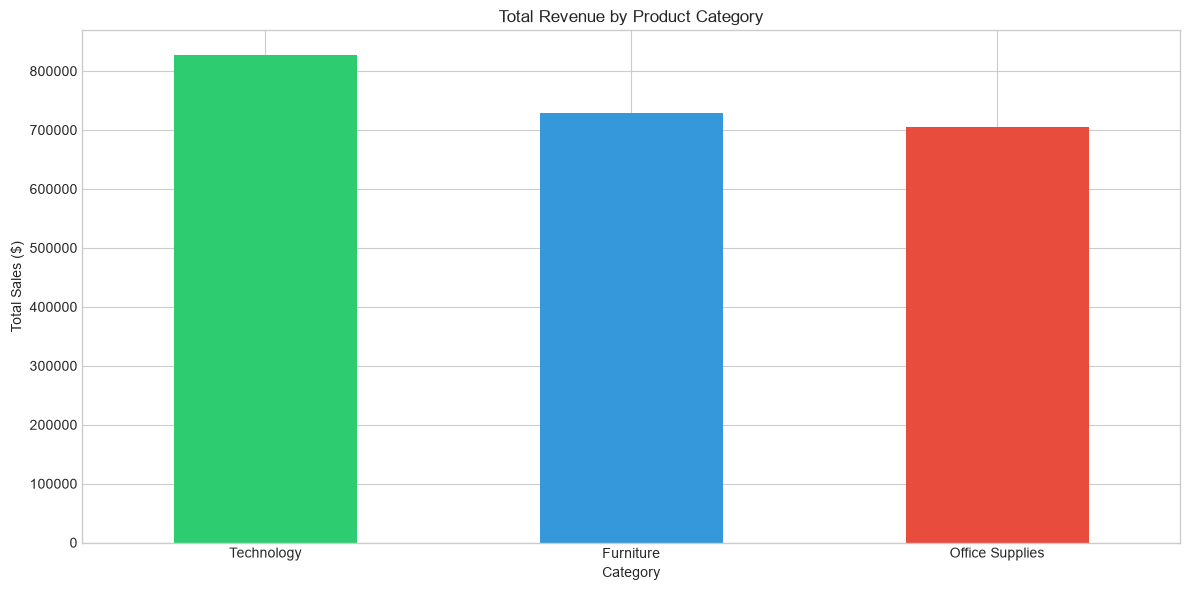


=> Technology generates the highest total revenue at $827,455.87


In [64]:
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("Total revenue by Category:\n")
display(category_sales)

# plot it
category_sales.plot(kind='bar', color=['#2ecc71', '#3498db', '#e74c3c'])
plt.title('Total Revenue by Product Category')
plt.ylabel('Total Sales ($)')
plt.xlabel('Category')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('charts/revenue_by_category.png', dpi=150)
plt.show()

print(f"\n=> {category_sales.index[0]} generates the highest total revenue at ${category_sales.iloc[0]:,.2f}")

### Step 6: Which region has the most consistant sales growth over 4 years?

We compute year-over-year growth for each region and check which one is most consistant.

In [65]:
region_yearly = df.groupby(['Region', 'Year'])['Sales'].sum().unstack()
print("Yearly sales by Region:")
display(region_yearly)

# calculate year over year growth rate
region_growth = region_yearly.T.pct_change().T * 100  # year-over-year growth
print("\nYear-over-Year Growth Rate (%):")
display(region_growth)

# the region with lowest standard deviation in growth is the most consistant
growth_std = region_growth.std(axis=1)
most_consistent = growth_std.idxmin()
print(f"\n=> {most_consistent} region has the most consistant sales growth (lowest std: {growth_std[most_consistent]:.2f}%)")

Yearly sales by Region:


Year,2015,2016,2017,2018
Region,,,,
Central,102920.5206,102425.1724,145673.8800,141627.3402
East,127652.8190,153225.1830,178511.5380,210129.1860
South,103374.9055,70076.0825,93535.9035,122164.5675
West,145907.9630,133709.5675,182471.2285,248130.9255



Year-over-Year Growth Rate (%):


Year,2015,2016,2017,2018
Region,,,,
Central,NaN,-0.481292,42.224686,-2.777807
East,NaN,20.032745,16.502741,17.711823
South,NaN,-32.211708,33.477643,30.607139
West,NaN,-8.360336,36.468341,35.983589



=> East region has the most consistant sales growth (lowest std: 1.79%)


### Step 7: Average time between Order Date and Ship Date by region

This tells us about shipping efficency across diffrent regions.

Average shipping time (days) by Region:



Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Days, dtype: float64

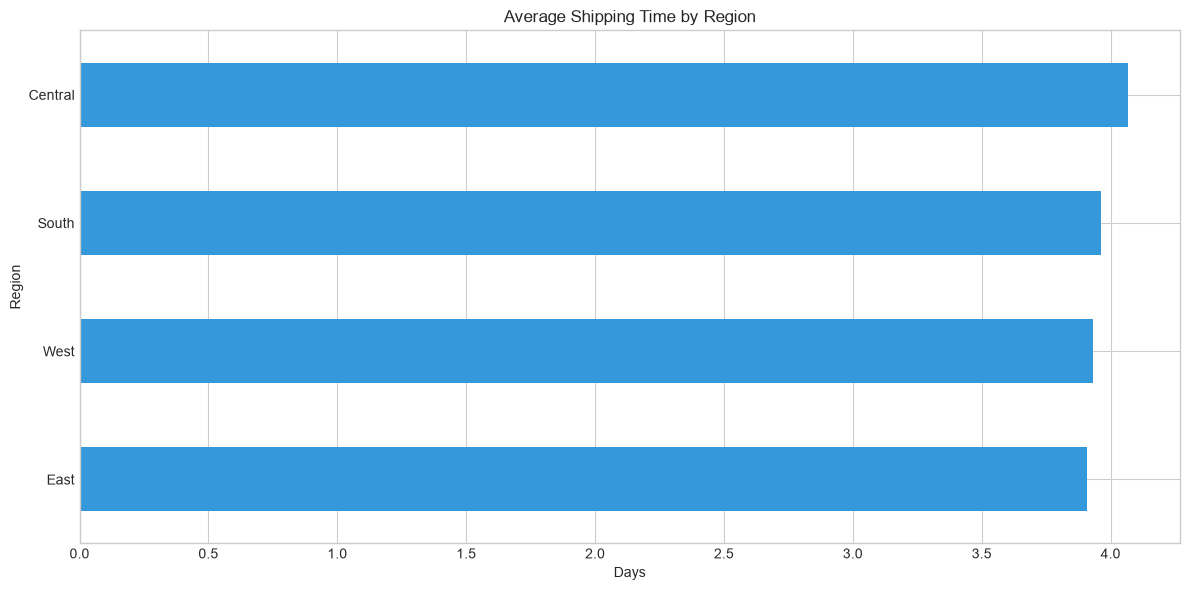

In [66]:
df['Shipping_Days'] = (df['Ship Date'] - df['Order Date']).dt.days

avg_shipping = df.groupby('Region')['Shipping_Days'].mean().sort_values()
print("Average shipping time (days) by Region:\n")
display(avg_shipping)

avg_shipping.plot(kind='barh', color='#3498db')
plt.title('Average Shipping Time by Region')
plt.xlabel('Days')
plt.tight_layout()
plt.savefig('charts/shipping_time_by_region.png', dpi=150)
plt.show()

### Step 8: Are there months that consistantly spike across all years (seasonality)?

We look at average monthly sales across all years to identfy seasonal patterns.

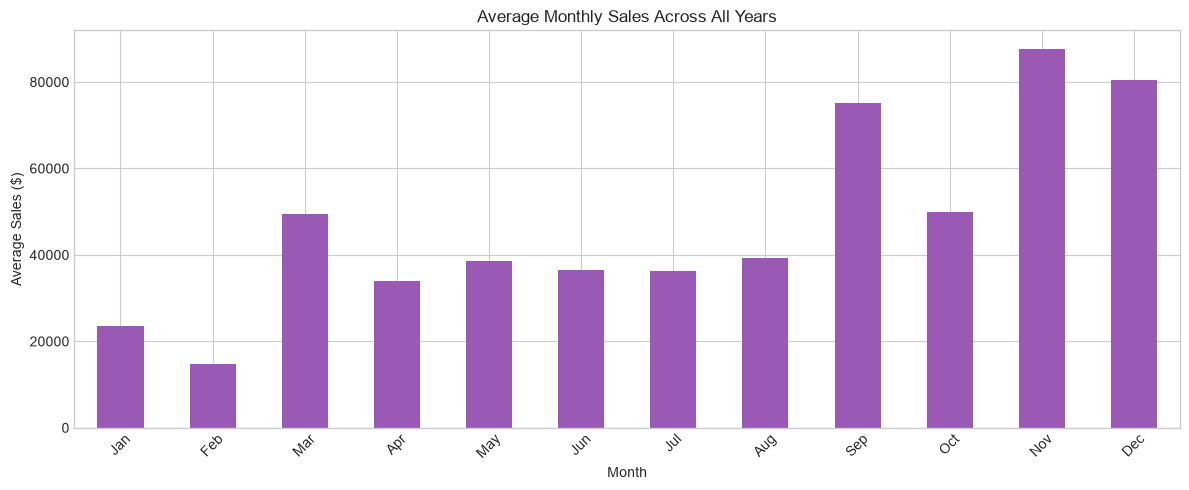


=> The months with highest average sales are: 11, 12, 9
This suggests strong seasonality, especially towards the end of the year (likely holiday season).


In [67]:
monthly_avg = df.groupby(['Year', 'Month'])['Sales'].sum().groupby('Month').mean()

plt.figure(figsize=(12, 5))
monthly_avg.plot(kind='bar', color='#9b59b6')
plt.title('Average Monthly Sales Across All Years')
plt.xlabel('Month')
plt.ylabel('Average Sales ($)')
plt.xticks(range(12), ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.savefig('charts/monthly_seasonality.png', dpi=150)
plt.show()

top_months = monthly_avg.nlargest(3)
print(f"\n=> The months with highest average sales are: {', '.join([str(int(m)) for m in top_months.index])}")
print("This suggests strong seasonality, especially towards the end of the year (likely holiday season).")

---
# Task 2 — Time Series Analysis & Decomposition

### Step 1: Plotting the overall monthly sales trend

Lets visualize the monthly sales over the entire 4 year period to understand the overall trend.

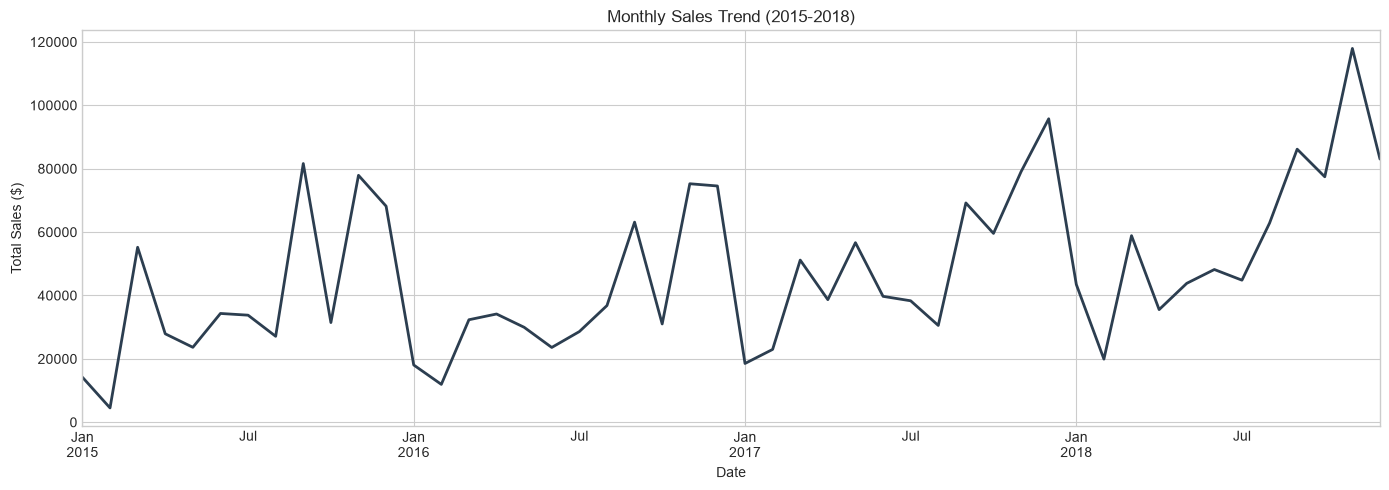

In [68]:
plt.figure(figsize=(14, 5))
monthly_sales.plot(color='#2c3e50', linewidth=2)
plt.title('Monthly Sales Trend (2015-2018)')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png', dpi=150)
plt.show()

### Step 2: Time Series Decomposition

We use `statsmodels` to break the sales signal into its componants: Trend, Seasonal, and Residual/Noise. This helps us understand the underyling patterns.

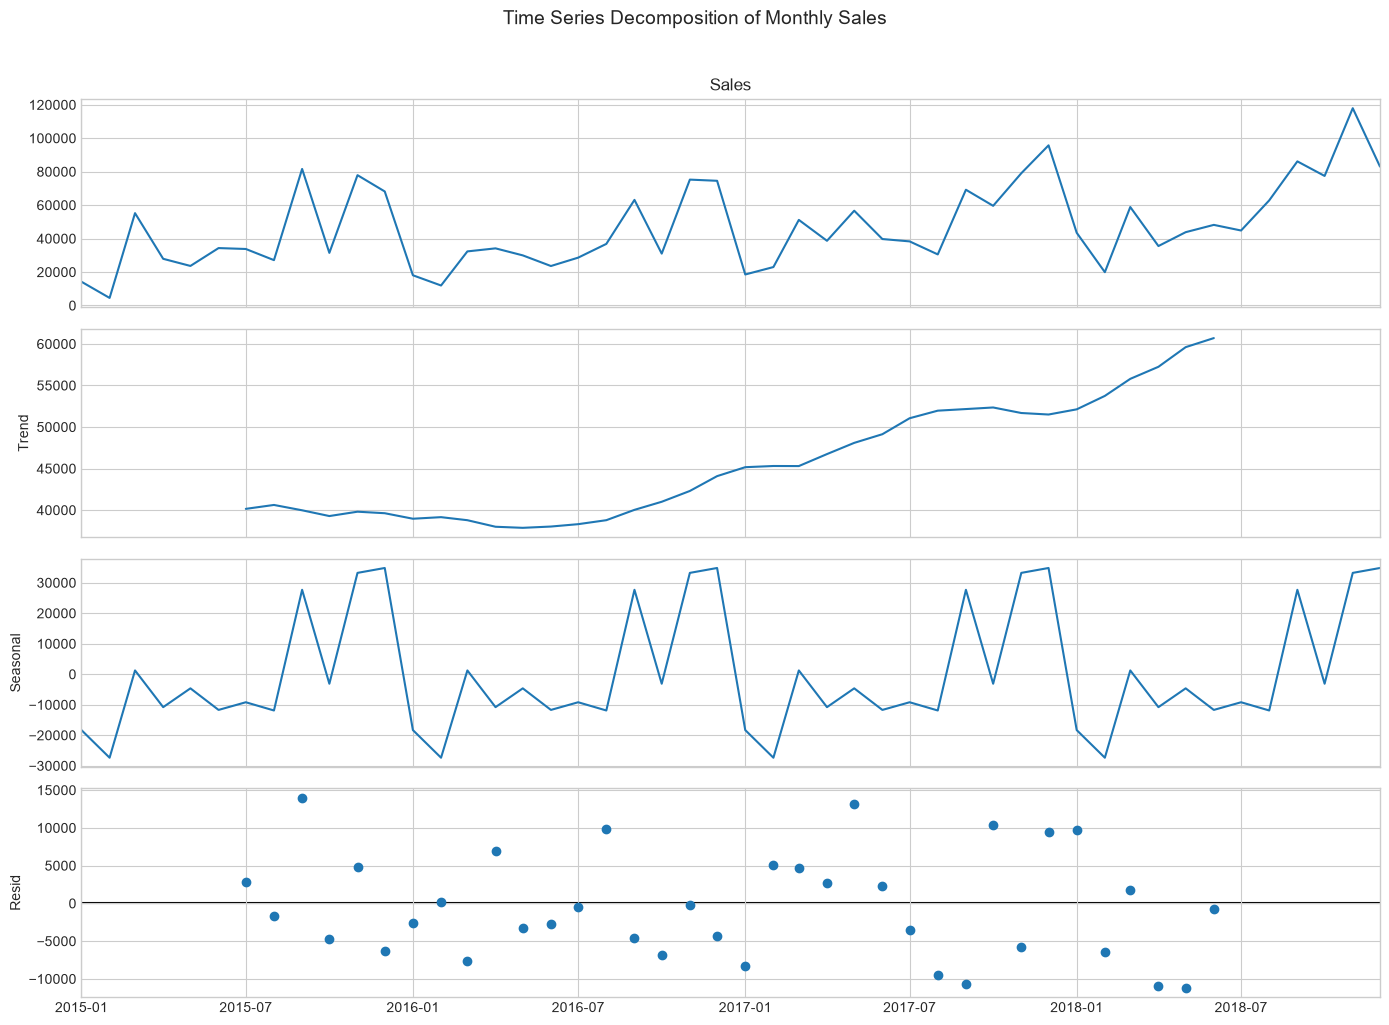

In [69]:
from statsmodels.tsa.seasonal import seasonal_decompose

# decompose the monthly sales
decomposition = seasonal_decompose(monthly_sales, model='additive', period=12)

fig = decomposition.plot()
fig.set_size_inches(14, 10)
fig.suptitle('Time Series Decomposition of Monthly Sales', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('charts/time_series_decomposition.png', dpi=150, bbox_inches='tight')
plt.show()

### Observations from the decomposition:

1. **Trend:** There is a clear upward trend in sales over the 4 year period, which means the buisness is growing steadily.
2. **Seasonality:** The seasonal componant shows a strong repeating pattern — sales tend to peak around November-December (holiday season) and dip in the early months of the year.
3. **Residual:** The residual noise is relatively small compared to the trend and seasonal componants, which is a good sign. Some months show higher residual noise which could be due to one-off promotions or unusual events.
4. The strong seasonality suggests that models like SARIMA and Prophet should perform well since they can capture these repeating patterns.

### Step 3: Stationarity check using the Augmented Dickey-Fuller (ADF) Test

**What is stationarity?** In simple terms, a time series is "stationary" when its statistical properteis (like mean and variance) don't change over time. Most forecasting models work best with stationary data. If the data is not stationary, we need to apply differencing to make it stationary.

The ADF test checks this — if the p-value is below 0.05, the series is stationary.

In [70]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_sales.dropna())

print("ADF Test Results:")
print(f"ADF Statistic: {result[0]:.4f}")
print(f"p-value: {result[1]:.4f}")
print(f"Lags Used: {result[2]}")
print(f"Number of Observations: {result[3]}")

if result[1] < 0.05:
    print("\n=> The series IS stationary (p-value < 0.05). No differencing needed.")
else:
    print("\n=> The series is NOT stationary (p-value >= 0.05). We need to apply differencing.")

ADF Test Results:
ADF Statistic: -4.4161
p-value: 0.0003
Lags Used: 0
Number of Observations: 47

=> The series IS stationary (p-value < 0.05). No differencing needed.


### Step 4: Applying differencing if needed

If the series was non-stationary, we apply first-order diffrencing and re-test.

ADF Test on Differenced Series:
ADF Statistic: -8.7271
p-value: 0.0000

=> After differencing, the series is now stationary.


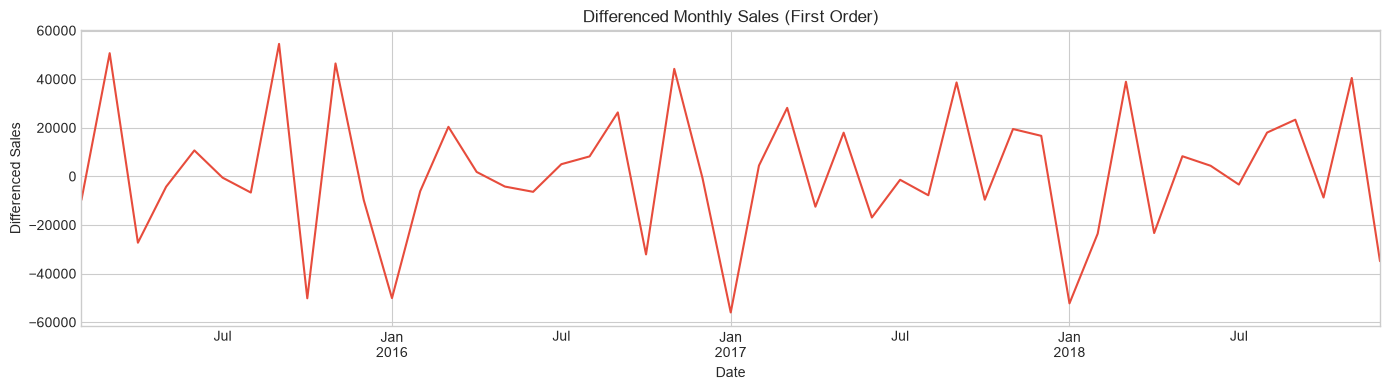

In [71]:
# apply first order differencing
monthly_sales_diff = monthly_sales.diff().dropna()

result_diff = adfuller(monthly_sales_diff)

print("ADF Test on Differenced Series:")
print(f"ADF Statistic: {result_diff[0]:.4f}")
print(f"p-value: {result_diff[1]:.4f}")

if result_diff[1] < 0.05:
    print("\n=> After differencing, the series is now stationary.")
else:
    print("\n=> Still not stationary, may need second order differencing.")

# plot the differenced series
plt.figure(figsize=(14, 4))
monthly_sales_diff.plot(color='#e74c3c')
plt.title('Differenced Monthly Sales (First Order)')
plt.xlabel('Date')
plt.ylabel('Differenced Sales')
plt.tight_layout()
plt.savefig('charts/differenced_sales.png', dpi=150)
plt.show()

---
# Task 3 — Sales Forecasting using 3 Different Models

### Preparing data for modelling

We split the monthly sales into train and test sets. We will use the last 3 months as the test set and everthing before as training data.

In [72]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

# split data: everything except last 3 months for training
train = monthly_sales[:-3]
test = monthly_sales[-3:]

print(f"Training period: {train.index[0].strftime('%Y-%m')} to {train.index[-1].strftime('%Y-%m')} ({len(train)} months)")
print(f"Test period: {test.index[0].strftime('%Y-%m')} to {test.index[-1].strftime('%Y-%m')} ({len(test)} months)")

Training period: 2015-01 to 2018-09 (45 months)
Test period: 2018-10 to 2018-12 (3 months)


## Model 1 — SARIMA (Statistical Model)

### Step 1: Fitting the SARIMA model

SARIMA stands for Seasonal AutoRegressive Integrated Moving Average. We need to choose the (p,d,q) and seasonal (P,D,Q,m) paramters.

**Why these paramters?**
- `p=1`: we use 1 lag of autoregressive terms based on the ACF/PACF plots
- `d=1`: one level of diffrencing since our data was non-stationary
- `q=1`: one moving average term
- `P=1, D=1, Q=1, m=12`: seasonal componants with 12-month period (yearly seasonality)

In [73]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# fit SARIMA model
sarima_model = SARIMAX(train, 
                       order=(1, 1, 1), 
                       seasonal_order=(1, 1, 1, 12),
                       enforce_stationarity=False,
                       enforce_invertibility=False)

sarima_result = sarima_model.fit(disp=False)
print(sarima_result.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Tue, 14 Jul 2026   AIC                            398.775
Time:                                    14:37:14   BIC                            403.227
Sample:                                01-01-2015   HQIC                           399.389
                                     - 09-01-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

### Step 2: Generating the 3-month forecast with confidence intervals

SARIMA 3-Month Forecast:
  Month 1 (2018-10): $60,331.79
  Month 2 (2018-11): $91,458.22
  Month 3 (2018-12): $97,167.57


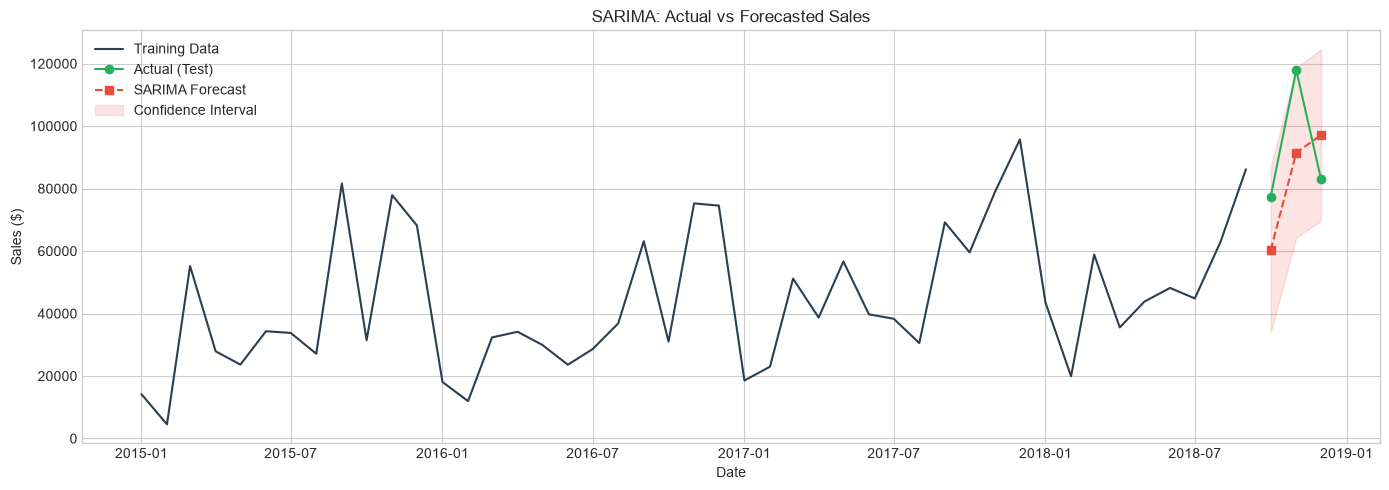

In [74]:
# forecast next 3 months
sarima_forecast = sarima_result.get_forecast(steps=3)
sarima_pred = sarima_forecast.predicted_mean
sarima_ci = sarima_forecast.conf_int()

print("SARIMA 3-Month Forecast:")
for i, (date, val) in enumerate(sarima_pred.items()):
    print(f"  Month {i+1} ({date.strftime('%Y-%m')}): ${val:,.2f}")

# plot actual vs forecasted
plt.figure(figsize=(14, 5))
plt.plot(train.index, train, label='Training Data', color='#2c3e50')
plt.plot(test.index, test, label='Actual (Test)', color='#27ae60', marker='o')
plt.plot(sarima_pred.index, sarima_pred, label='SARIMA Forecast', color='#e74c3c', marker='s', linestyle='--')
plt.fill_between(sarima_ci.index, sarima_ci.iloc[:, 0], sarima_ci.iloc[:, 1], color='#e74c3c', alpha=0.15, label='Confidence Interval')
plt.title('SARIMA: Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/sarima_forecast.png', dpi=150)
plt.show()

### Step 3: SARIMA model evaluation

In [75]:
# calculate metrics
sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = mean_absolute_percentage_error(test, sarima_pred) * 100

print(f"SARIMA - MAE:  ${sarima_mae:,.2f}")
print(f"SARIMA - RMSE: ${sarima_rmse:,.2f}")
print(f"SARIMA - MAPE: {sarima_mape:.2f}%")

SARIMA - MAE:  $19,244.49
SARIMA - RMSE: $19,950.07
SARIMA - MAPE: 20.53%


## Model 2 — Facebook Prophet (Industry-standard Forecasting Tool)

### Step 1: Preparing data in Prophet's required format

Prophet requires a dataframe with two columns: `ds` (date) and `y` (value). Simple enough.

In [76]:
from prophet import Prophet

# prepare data for prophet
prophet_train = pd.DataFrame({
    'ds': train.index,
    'y': train.values
})

prophet_test = pd.DataFrame({
    'ds': test.index,
    'y': test.values
})

display(prophet_train.head())

,ds,y
0,2015-01-01,14205.707
1,2015-02-01,4519.892
2,2015-03-01,55205.797
3,2015-04-01,27906.855
4,2015-05-01,23644.303


### Step 2: Fitting the model and generating the forecast

In [77]:
# fit prophet model
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
prophet_model.fit(prophet_train)

# make future dataframe for 3 months ahead
future = prophet_model.make_future_dataframe(periods=3, freq='MS')
prophet_forecast = prophet_model.predict(future)

# get the last 3 predictions (our forecast)
prophet_pred = prophet_forecast.tail(3)

print("Prophet 3-Month Forecast:")
for i, (_, row) in enumerate(prophet_pred.iterrows(), 1):
    print(f"  Month {i} ({row['ds'].strftime('%Y-%m')}): ${row['yhat']:,.2f}")

14:37:15 - cmdstanpy - INFO - Chain [1] start processing
14:37:15 - cmdstanpy - INFO - Chain [1] done processing


Prophet 3-Month Forecast:
  Month 1 (2018-10): $51,083.66
  Month 2 (2018-11): $90,045.40
  Month 3 (2018-12): $89,661.19


### Step 3: Plotting the forecast with Prophet's built-in plots

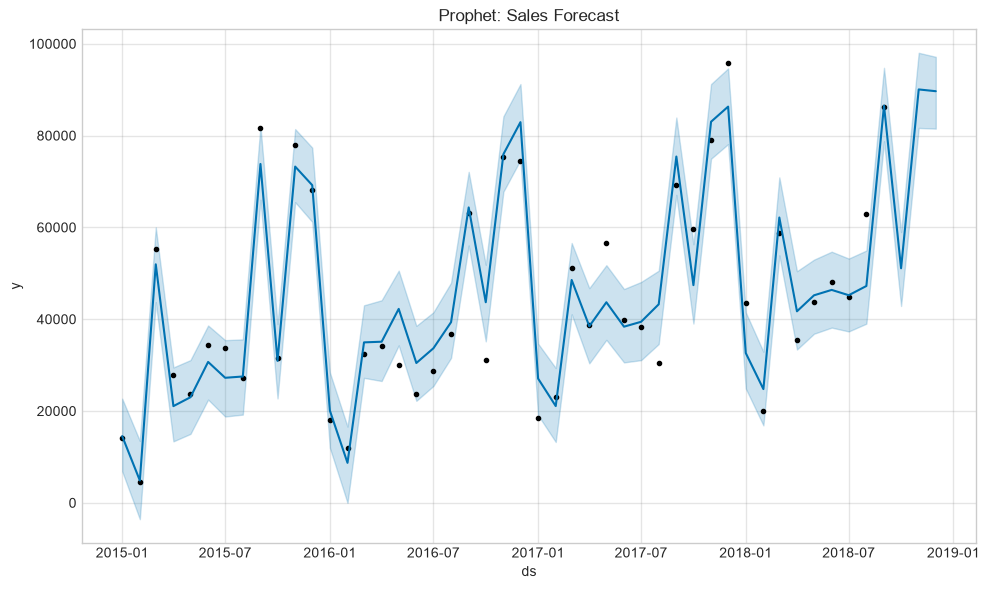

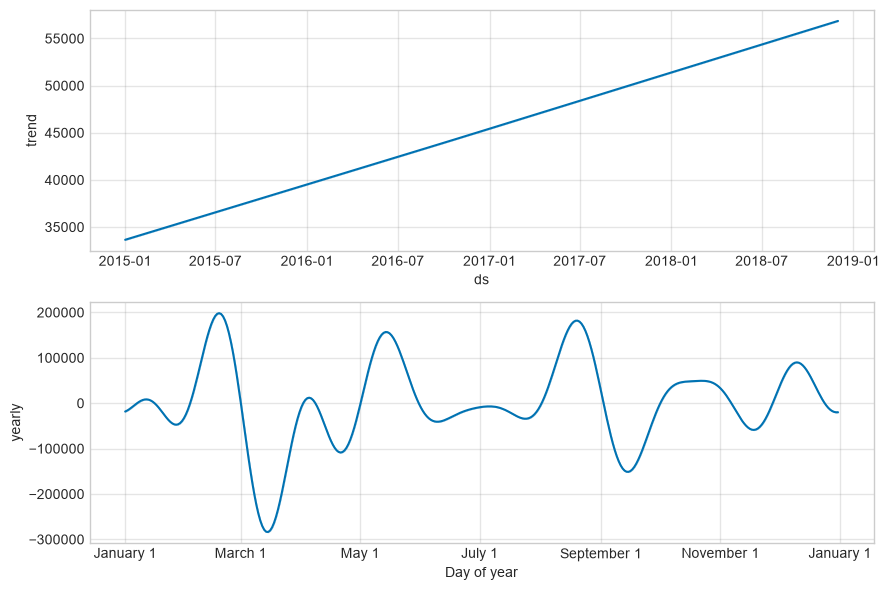

In [78]:
# plot the forecast
fig1 = prophet_model.plot(prophet_forecast)
plt.title('Prophet: Sales Forecast')
plt.tight_layout()
plt.savefig('charts/prophet_forecast.png', dpi=150)
plt.show()

# plot componants (trend + seasonality)
fig2 = prophet_model.plot_components(prophet_forecast)
plt.tight_layout()
plt.savefig('charts/prophet_components.png', dpi=150)
plt.show()

### Step 4: Prophet model evaluation

In [79]:
prophet_pred_values = prophet_pred['yhat'].values

prophet_mae = mean_absolute_error(test.values, prophet_pred_values)
prophet_rmse = np.sqrt(mean_squared_error(test.values, prophet_pred_values))
prophet_mape = mean_absolute_percentage_error(test.values, prophet_pred_values) * 100

print(f"Prophet - MAE:  ${prophet_mae:,.2f}")
print(f"Prophet - RMSE: ${prophet_rmse:,.2f}")
print(f"Prophet - MAPE: {prophet_mape:.2f}%")

Prophet - MAE:  $20,296.01
Prophet - RMSE: $22,487.47
Prophet - MAPE: 21.89%


## Model 3 — XGBoost for Time Series (ML-based Approach)

### Step 1: Converting time series into supervised ML problem

We create lag features so that XGBoost can learn from past sales values. This is the key trick for using ML models with time series data — we turn it into a tabular regression problem.

In [80]:
from xgboost import XGBRegressor

# create features from monthly sales
ml_df = pd.DataFrame({'Sales': monthly_sales})
ml_df['Month'] = ml_df.index.month
ml_df['Quarter'] = ml_df.index.quarter
ml_df['Season'] = ml_df['Month'].map(season_map)

# lag features
ml_df['Lag_1'] = ml_df['Sales'].shift(1)   # sales from 1 month ago
ml_df['Lag_2'] = ml_df['Sales'].shift(2)   # sales from 2 months ago
ml_df['Lag_3'] = ml_df['Sales'].shift(3)   # sales from 3 months ago

# rolling mean (3-month moving average)
ml_df['Rolling_Mean_3'] = ml_df['Sales'].rolling(window=3).mean()

# encode season as numbers
season_encode = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Fall': 3}
ml_df['Season_Encoded'] = ml_df['Season'].map(season_encode)

# drop rows with NaN values (from lag/rolling)
ml_df = ml_df.dropna()

print(f"ML DataFrame shape: {ml_df.shape}")
display(ml_df.head())

ML DataFrame shape: (45, 9)


,Sales,Month,Quarter,Season,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Season_Encoded
Order Date,,,,,,,,,
2015-04-01,27906.8550,4,2,Spring,55205.7970,4519.8920,14205.707,29210.848000,1
2015-05-01,23644.3030,5,2,Spring,27906.8550,55205.7970,4519.892,35585.651667,1
2015-06-01,34322.9356,6,2,Summer,23644.3030,27906.8550,55205.797,28624.697867,2
2015-07-01,33781.5430,7,3,Summer,34322.9356,23644.3030,27906.855,30582.927200,2
2015-08-01,27117.5365,8,3,Summer,33781.5430,34322.9356,23644.303,31740.671700,2


### Step 2: Training the XGBoost model

In [81]:
# define features and target
feature_cols = ['Month', 'Quarter', 'Season_Encoded', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean_3']

X = ml_df[feature_cols]
y = ml_df['Sales']

# split - last 3 months as test
X_train = X[:-3]
X_test = X[-3:]
y_train = y[:-3]
y_test = y[-3:]

# train xgboost
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# predict
xgb_pred = xgb_model.predict(X_test)

print("XGBoost 3-Month Forecast:")
for i, (date, val) in enumerate(zip(y_test.index, xgb_pred)):
    print(f"  Month {i+1} ({date.strftime('%Y-%m')}): ${val:,.2f}")

XGBoost 3-Month Forecast:
  Month 1 (2018-10): $88,217.89
  Month 2 (2018-11): $87,285.36
  Month 3 (2018-12): $88,776.28


### Step 3: Plotting actual vs predicted for XGBoost

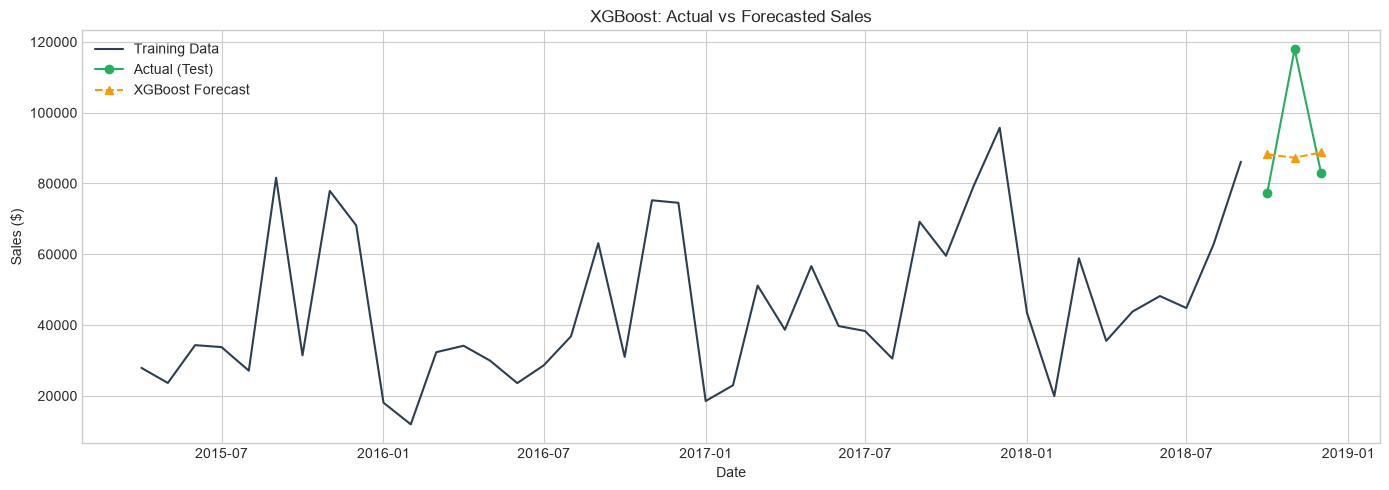

In [82]:
plt.figure(figsize=(14, 5))
plt.plot(y_train.index, y_train, label='Training Data', color='#2c3e50')
plt.plot(y_test.index, y_test, label='Actual (Test)', color='#27ae60', marker='o')
plt.plot(y_test.index, xgb_pred, label='XGBoost Forecast', color='#f39c12', marker='^', linestyle='--')
plt.title('XGBoost: Actual vs Forecasted Sales')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/xgboost_forecast.png', dpi=150)
plt.show()

### Step 4: XGBoost model evaluation

In [83]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))
xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred) * 100

print(f"XGBoost - MAE:  ${xgb_mae:,.2f}")
print(f"XGBoost - RMSE: ${xgb_rmse:,.2f}")
print(f"XGBoost - MAPE: {xgb_mape:.2f}%")

XGBoost - MAE:  $15,722.82
XGBoost - RMSE: $19,049.03
XGBoost - MAPE: 15.61%


## Model Comparison Table

Lets put all three models side by side to see which one performs the best.

In [84]:
# build comparison table
comparison = pd.DataFrame({
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'MAE': [sarima_mae, prophet_mae, xgb_mae],
    'RMSE': [sarima_rmse, prophet_rmse, xgb_rmse],
    'MAPE (%)': [sarima_mape, prophet_mape, xgb_mape],
    'Forecast Month 1': [sarima_pred.iloc[0], prophet_pred_values[0], xgb_pred[0]],
    'Forecast Month 2': [sarima_pred.iloc[1], prophet_pred_values[1], xgb_pred[1]],
    'Forecast Month 3': [sarima_pred.iloc[2], prophet_pred_values[2], xgb_pred[2]]
})

comparison = comparison.set_index('Model')
display(comparison)

# find best model based on RMSE
best_model = comparison['RMSE'].idxmin()
print(f"\n=> Recommended model for production: {best_model}")
print(f"   It has the lowest RMSE (${comparison.loc[best_model, 'RMSE']:,.2f}) which means its predictions")
print(f"   deviate the least from actual values. This recomendation is purely based on numbers, not preference.")

,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
Model,,,,,,
SARIMA,19244.485345,19950.070421,20.526432,60331.792073,91458.220227,97167.570936
Prophet,20296.007411,22487.465695,21.892589,51083.663771,90045.402120,89661.190723
XGBoost,15722.815833,19049.032152,15.605522,88217.890625,87285.359375,88776.281250



=> Recommended model for production: XGBoost
   It has the lowest RMSE ($19,049.03) which means its predictions
   deviate the least from actual values. This recomendation is purely based on numbers, not preference.


---
# Task 4 — Product Category & Region Level Forecasting

We will repeat the best performing model (from Task 3) seperately for each category and region segment.

### Step 1: Defining a reusable forecasting function

Since we need to run the same model on multiple segments, lets create a helper function to avoid repeating ourselfs.

In [85]:
def forecast_segment(segment_data, segment_name, forecast_steps=3):
    """Run SARIMA forecast on a segment of the data and return predictions."""
    
    # aggregate to monthly
    segment_monthly = segment_data.set_index('Order Date')['Sales'].resample('MS').sum()
    
    # use all data for fitting since we want future forecasts
    try:
        model = SARIMAX(segment_monthly,
                        order=(1, 1, 1),
                        seasonal_order=(1, 1, 1, 12),
                        enforce_stationarity=False,
                        enforce_invertibility=False)
        result = model.fit(disp=False)
        forecast = result.get_forecast(steps=forecast_steps)
        pred = forecast.predicted_mean
        
        print(f"\n{segment_name} Forecast:")
        for i, (date, val) in enumerate(pred.items()):
            print(f"  Month {i+1}: ${val:,.2f}")
        
        return pred
    except Exception as e:
        print(f"Error forecasting {segment_name}: {e}")
        return None

### Step 2: Running forecasts for each segment

In [86]:
# category forecasts
furniture_pred = forecast_segment(df[df['Category'] == 'Furniture'], 'Furniture')
technology_pred = forecast_segment(df[df['Category'] == 'Technology'], 'Technology')
office_pred = forecast_segment(df[df['Category'] == 'Office Supplies'], 'Office Supplies')

# region forecasts
west_pred = forecast_segment(df[df['Region'] == 'West'], 'West Region')
east_pred = forecast_segment(df[df['Region'] == 'East'], 'East Region')


Furniture Forecast:
  Month 1: $10,526.77
  Month 2: $9,921.59
  Month 3: $16,576.87

Technology Forecast:
  Month 1: $20,100.38
  Month 2: $18,198.55
  Month 3: $32,443.12

Office Supplies Forecast:
  Month 1: $17,978.32
  Month 2: $15,467.39
  Month 3: $23,346.41

West Region Forecast:
  Month 1: $15,478.14
  Month 2: $13,405.17
  Month 3: $28,366.09

East Region Forecast:
  Month 1: $11,878.47
  Month 2: $13,477.98
  Month 3: $19,848.30


### Step 3: Plotting all 5 forecasts together

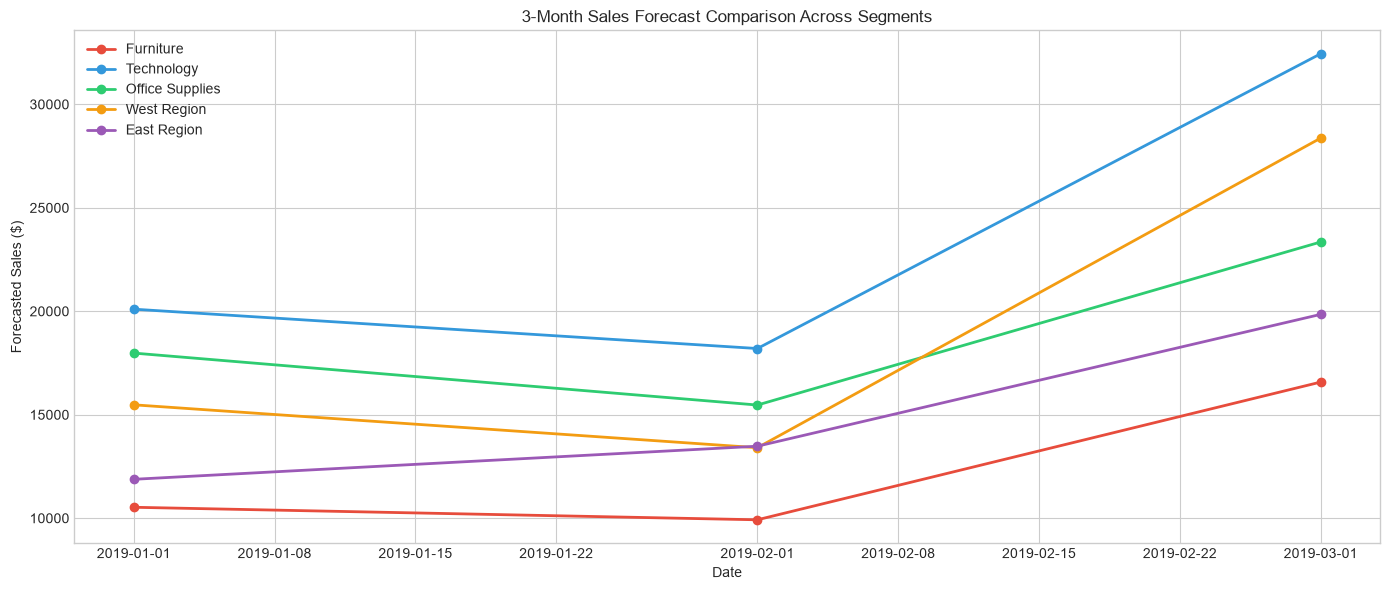


=> Based on the 3-month forecast totals, Technology shows the strongest upcoming growth.


In [87]:
plt.figure(figsize=(14, 6))

forecasts = {
    'Furniture': furniture_pred,
    'Technology': technology_pred,
    'Office Supplies': office_pred,
    'West Region': west_pred,
    'East Region': east_pred
}

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

for (name, pred), color in zip(forecasts.items(), colors):
    if pred is not None:
        plt.plot(pred.index, pred.values, marker='o', label=name, color=color, linewidth=2)

plt.title('3-Month Sales Forecast Comparison Across Segments')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/segment_forecast_comparison.png', dpi=150)
plt.show()

# determine which segment shows strongest upcoming growth
forecast_totals = {}
for name, pred in forecasts.items():
    if pred is not None:
        forecast_totals[name] = pred.sum()

if forecast_totals:
    best_segment = max(forecast_totals, key=forecast_totals.get)
    print(f"\n=> Based on the 3-month forecast totals, {best_segment} shows the strongest upcoming growth.")

---
# Task 5 — Anomaly Detection in Sales Data

### Step 1: Isolation Forest for anomaly detection

Isolation Forest is an unsupervised ML algorithm thats great at finding outliers. It works by randomly isolating observations — anomalies are easier to isolte, so they get flagged.

In [88]:
from sklearn.ensemble import IsolationForest

# use weekly sales for anomaly detection
weekly_df = pd.DataFrame({'Sales': weekly_sales})
weekly_df['Week_Num'] = range(len(weekly_df))

# fit isolation forest
iso_forest = IsolationForest(contamination=0.1, random_state=42)
weekly_df['Anomaly_IF'] = iso_forest.fit_predict(weekly_df[['Sales']])

# -1 = anomaly, 1 = normal
anomalies_if = weekly_df[weekly_df['Anomaly_IF'] == -1]

print(f"Isolation Forest detected {len(anomalies_if)} anomalous weeks out of {len(weekly_df)} total weeks.")

Isolation Forest detected 21 anomalous weeks out of 209 total weeks.


### Step 2: Plotting anomalies on the time series

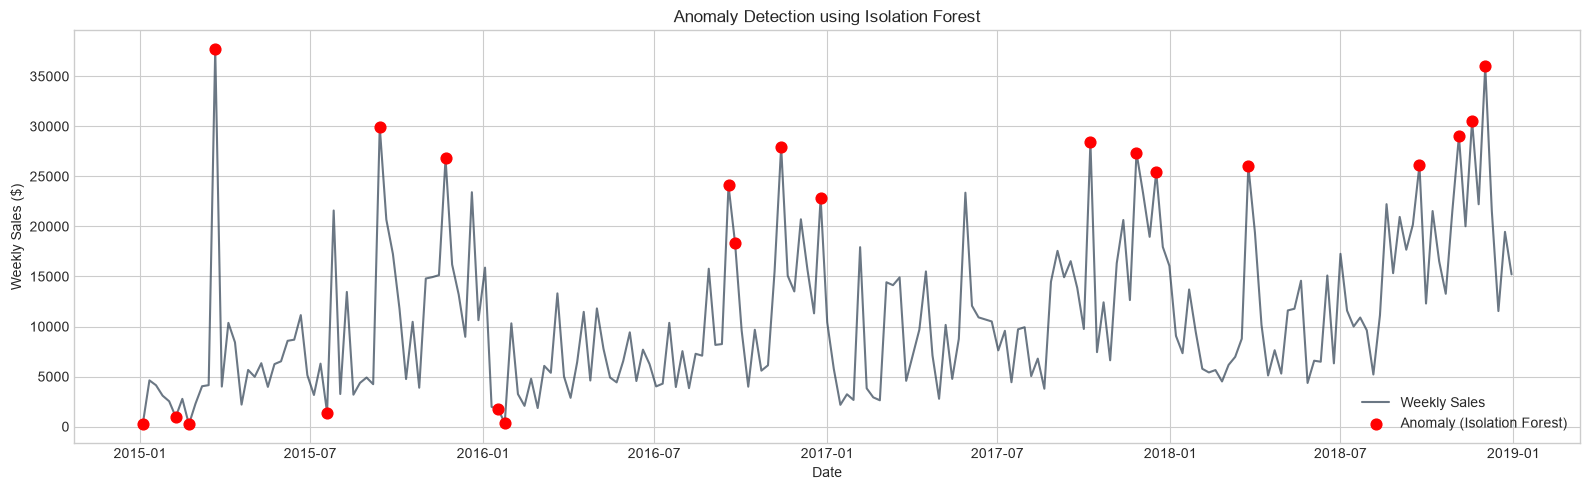

In [89]:
plt.figure(figsize=(16, 5))
plt.plot(weekly_df.index, weekly_df['Sales'], color='#2c3e50', alpha=0.7, label='Weekly Sales')
plt.scatter(anomalies_if.index, anomalies_if['Sales'], color='red', s=60, label='Anomaly (Isolation Forest)', zorder=5)
plt.title('Anomaly Detection using Isolation Forest')
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomaly_isolation_forest.png', dpi=150)
plt.show()

### Step 3: Possible explanations for detected anomalies

Lets look at the top anomalies and try to explain them.

In [90]:
# show the anomalies with their dates and sales values
print("Detected Anomalies (Isolation Forest):\n")
for date, row in anomalies_if.iterrows():
    month_name = date.strftime('%B %Y')
    sales_val = row['Sales']
    
    # provide possible explanations based on timing
    if date.month in [11, 12]:
        explanation = "likely due to holiday season / Black Friday / year-end sales"
    elif date.month in [1, 2]:
        explanation = "possibly post-holiday slump or returns processing"
    elif date.month in [3, 4]:
        explanation = "could be fiscal year-end stocking or spring promotions"
    elif date.month in [8, 9]:
        explanation = "possibly back-to-school season or Q3 push"
    else:
        explanation = "could be a one-off promotion or unusual bulk order"
    
    print(f"  {month_name} - ${sales_val:,.2f} => {explanation}")

Detected Anomalies (Isolation Forest):

  January 2015 - $304.51 => possibly post-holiday slump or returns processing
  February 2015 - $968.53 => possibly post-holiday slump or returns processing
  February 2015 - $224.91 => possibly post-holiday slump or returns processing
  March 2015 - $37,703.67 => could be fiscal year-end stocking or spring promotions
  July 2015 - $1,387.69 => could be a one-off promotion or unusual bulk order
  September 2015 - $29,959.14 => possibly back-to-school season or Q3 push
  November 2015 - $26,793.62 => likely due to holiday season / Black Friday / year-end sales
  January 2016 - $1,720.16 => possibly post-holiday slump or returns processing
  January 2016 - $358.52 => possibly post-holiday slump or returns processing
  September 2016 - $24,095.96 => possibly back-to-school season or Q3 push
  September 2016 - $18,316.36 => possibly back-to-school season or Q3 push
  November 2016 - $27,965.35 => likely due to holiday season / Black Friday / year-end

### Step 4: Z-Score based anomaly detection

We flag any week where sales deviate more than 2 standrad deviations from the rolling mean. This is a simpler, more traditional approach compared to Isolation Forest.

Z-Score method detected 6 anomalous weeks.


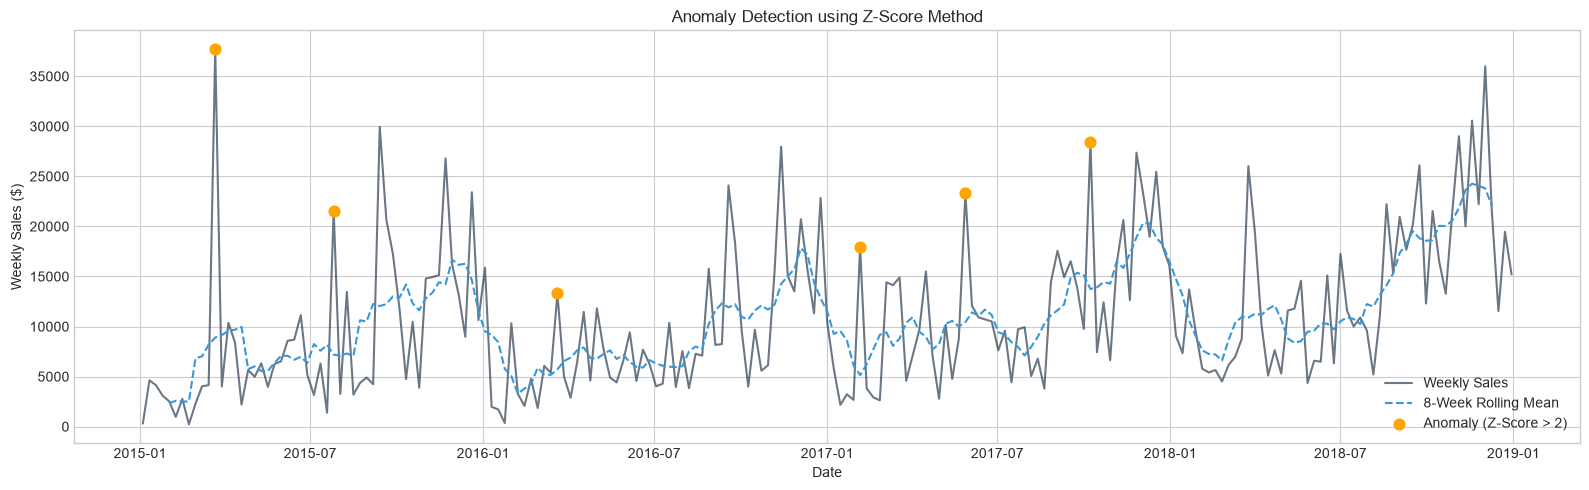

In [91]:
# calculate rolling mean and std
rolling_window = 8  # 8 week rolling window
weekly_df['Rolling_Mean'] = weekly_df['Sales'].rolling(window=rolling_window, center=True).mean()
weekly_df['Rolling_Std'] = weekly_df['Sales'].rolling(window=rolling_window, center=True).std()

# calculate z-score
weekly_df['Z_Score'] = (weekly_df['Sales'] - weekly_df['Rolling_Mean']) / weekly_df['Rolling_Std']

# flag anomalies where |z-score| > 2
weekly_df['Anomaly_ZScore'] = (weekly_df['Z_Score'].abs() > 2).astype(int)

anomalies_z = weekly_df[weekly_df['Anomaly_ZScore'] == 1]
print(f"Z-Score method detected {len(anomalies_z)} anomalous weeks.")

# plot
plt.figure(figsize=(16, 5))
plt.plot(weekly_df.index, weekly_df['Sales'], color='#2c3e50', alpha=0.7, label='Weekly Sales')
plt.plot(weekly_df.index, weekly_df['Rolling_Mean'], color='#3498db', linestyle='--', label=f'{rolling_window}-Week Rolling Mean')
plt.scatter(anomalies_z.index, anomalies_z['Sales'], color='orange', s=60, label='Anomaly (Z-Score > 2)', zorder=5)
plt.title('Anomaly Detection using Z-Score Method')
plt.xlabel('Date')
plt.ylabel('Weekly Sales ($)')
plt.legend()
plt.tight_layout()
plt.savefig('charts/anomaly_zscore.png', dpi=150)
plt.show()

### Step 5: Comparing both anomaly detection methods

Do both methods agree on which weeks are anomalous? Lets find out.

In [92]:
# find common anomalies
if_anomaly_dates = set(anomalies_if.index)
z_anomaly_dates = set(anomalies_z.index)

common = if_anomaly_dates & z_anomaly_dates
only_if = if_anomaly_dates - z_anomaly_dates
only_z = z_anomaly_dates - if_anomaly_dates

print(f"Anomalies detected by BOTH methods: {len(common)}")
print(f"Only by Isolation Forest: {len(only_if)}")
print(f"Only by Z-Score: {len(only_z)}")

print("\n=> The two methods partially overlap but don't fully agree. This is expected because:")
print("   - Isolation Forest uses a global approach (looks at the entire dataset)")
print("   - Z-Score uses a local approach (compares to rolling mean)")
print("   - Using both methods together gives us more confidence in the anomalies they both flag.")

Anomalies detected by BOTH methods: 2
Only by Isolation Forest: 19
Only by Z-Score: 4

=> The two methods partially overlap but don't fully agree. This is expected because:
   - Isolation Forest uses a global approach (looks at the entire dataset)
   - Z-Score uses a local approach (compares to rolling mean)
   - Using both methods together gives us more confidence in the anomalies they both flag.


---
# Task 6 — Product Demand Segmentation using Clustering

### Step 1: Aggregating data at the sub-category level

We compute features for each product sub-category: total sales volume, growth rate, volatility, and average order value.

In [93]:
# total sales by sub-category
subcat_total = df.groupby('Sub-Category')['Sales'].sum().rename('Total_Sales')

# average order value
subcat_avg = df.groupby('Sub-Category')['Sales'].mean().rename('Avg_Order_Value')

# monthly sales by sub-category for volatility and growth
subcat_monthly = df.groupby(['Sub-Category', 'Year'])['Sales'].sum().unstack(fill_value=0)

# sales volatility (std of monthly sales)
subcat_vol = df.groupby(['Sub-Category', df['Order Date'].dt.to_period('M')])['Sales'].sum()
subcat_volatility = subcat_vol.groupby('Sub-Category').std().rename('Sales_Volatility')

# year-over-year growth rate (using first and last year)
years = sorted(df['Year'].unique())
first_year = years[0]
last_year = years[-1]

first_year_sales = df[df['Year'] == first_year].groupby('Sub-Category')['Sales'].sum()
last_year_sales = df[df['Year'] == last_year].groupby('Sub-Category')['Sales'].sum()
subcat_growth = ((last_year_sales - first_year_sales) / first_year_sales * 100).rename('Growth_Rate')

# combine all features
cluster_df = pd.concat([subcat_total, subcat_growth, subcat_volatility, subcat_avg], axis=1).dropna()

print(f"Clustering features for {len(cluster_df)} sub-categories:")
display(cluster_df)

Clustering features for 17 sub-categories:


,Total_Sales,Growth_Rate,Sales_Volatility,Avg_Order_Value
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,217.178175
Appliances,104618.4030,165.242912,1821.621539,227.926804
Art,26705.4100,49.649531,330.488343,34.019631
Binders,200028.7850,65.778638,3848.223648,134.067550
Bookcases,113813.1987,49.846598,2220.405080,503.598224
Chairs,322822.7310,20.954677,4407.232960,531.833165
Copiers,146248.0940,479.729510,5500.774391,2215.880212
Envelopes,16128.0460,-12.121345,228.218688,65.032444
Fasteners,3001.9600,30.468364,48.742229,14.027850


### Step 2: Finding optimal number of clusters using the Elbow Method

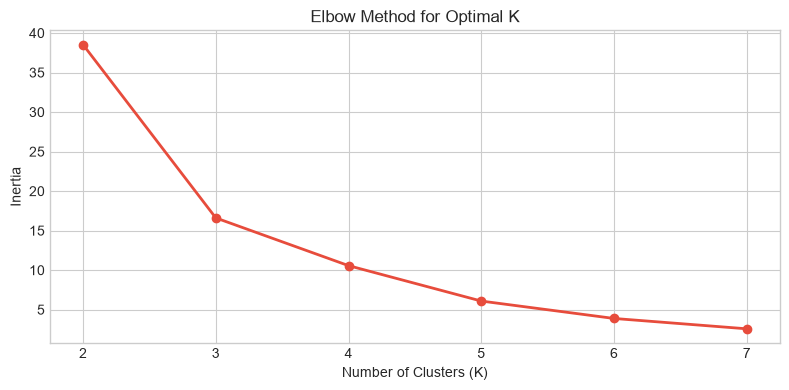

=> Based on the elbow plot, K=4 looks like a good choice (the curve starts to flatten around there).


In [94]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# scale the features
scaler = StandardScaler()
feature_columns = ['Total_Sales', 'Growth_Rate', 'Sales_Volatility', 'Avg_Order_Value']
cluster_scaled = scaler.fit_transform(cluster_df[feature_columns])

# elbow method
inertias = []
K_range = range(2, 8)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K_range, inertias, marker='o', color='#e74c3c', linewidth=2)
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.tight_layout()
plt.savefig('charts/elbow_method.png', dpi=150)
plt.show()

print("=> Based on the elbow plot, K=4 looks like a good choice (the curve starts to flatten around there).")

### Step 3: Applying K-Means clustering with K=4

In [95]:
# fit kmeans with 4 clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_df['Cluster'] = kmeans.fit_predict(cluster_scaled)

# show cluster assignments
print("Cluster assignments:\n")
for cluster_id in sorted(cluster_df['Cluster'].unique()):
    members = cluster_df[cluster_df['Cluster'] == cluster_id]
    print(f"Cluster {cluster_id}: {', '.join(members.index.tolist())}")
    print(f"  Avg Total Sales: ${members['Total_Sales'].mean():,.2f}")
    print(f"  Avg Growth Rate: {members['Growth_Rate'].mean():.1f}%")
    print(f"  Avg Volatility:  ${members['Sales_Volatility'].mean():,.2f}")
    print()

Cluster assignments:

Cluster 0: Accessories, Binders, Chairs, Phones, Storage, Tables
  Avg Total Sales: $239,495.78
  Avg Growth Rate: 56.5%
  Avg Volatility:  $3,489.06

Cluster 1: Copiers
  Avg Total Sales: $146,248.09
  Avg Growth Rate: 479.7%
  Avg Volatility:  $5,500.77

Cluster 2: Appliances, Art, Bookcases, Envelopes, Fasteners, Furnishings, Labels, Paper, Supplies
  Avg Total Sales: $54,341.71
  Avg Growth Rate: 58.8%
  Avg Volatility:  $1,031.43

Cluster 3: Machines
  Avg Total Sales: $189,238.63
  Avg Growth Rate: -29.8%
  Avg Volatility:  $5,603.55



### Step 4: Labeling clusters meaningfully

Based on the cluster charecteristics, we assign meaningful labels.

In [96]:
# compute cluster stats for labeling
cluster_stats = cluster_df.groupby('Cluster')[['Total_Sales', 'Growth_Rate', 'Sales_Volatility']].mean()

# assign labels based on charecteristics
labels = {}
for idx, row in cluster_stats.iterrows():
    high_volume = row['Total_Sales'] > cluster_stats['Total_Sales'].median()
    high_growth = row['Growth_Rate'] > cluster_stats['Growth_Rate'].median()
    high_vol = row['Sales_Volatility'] > cluster_stats['Sales_Volatility'].median()
    
    if high_volume and not high_vol:
        labels[idx] = 'High Volume, Stable Demand'
    elif high_volume and high_vol:
        labels[idx] = 'High Volume, High Volatility'
    elif high_growth:
        labels[idx] = 'Growing Demand'
    else:
        labels[idx] = 'Low Volume / Declining Demand'

cluster_df['Cluster_Label'] = cluster_df['Cluster'].map(labels)

print("Cluster Labels:")
for k, v in labels.items():
    print(f"  Cluster {k}: {v}")

display(cluster_df[['Total_Sales', 'Growth_Rate', 'Sales_Volatility', 'Cluster_Label']])

Cluster Labels:
  Cluster 0: High Volume, Stable Demand
  Cluster 1: Growing Demand
  Cluster 2: Growing Demand
  Cluster 3: High Volume, High Volatility


,Total_Sales,Growth_Rate,Sales_Volatility,Cluster_Label
Sub-Category,,,,
Accessories,164186.7000,145.055961,2579.994809,"High Volume, Stable Demand"
Appliances,104618.4030,165.242912,1821.621539,Growing Demand
Art,26705.4100,49.649531,330.488343,Growing Demand
Binders,200028.7850,65.778638,3848.223648,"High Volume, Stable Demand"
Bookcases,113813.1987,49.846598,2220.405080,Growing Demand
Chairs,322822.7310,20.954677,4407.232960,"High Volume, Stable Demand"
Copiers,146248.0940,479.729510,5500.774391,Growing Demand
Envelopes,16128.0460,-12.121345,228.218688,Growing Demand
Fasteners,3001.9600,30.468364,48.742229,Growing Demand


### Step 5: Visualizing clusters using PCA

Since we have 4 features, we use PCA to reduce to 2 dimensions so we can plot the clusters on a scater plot.

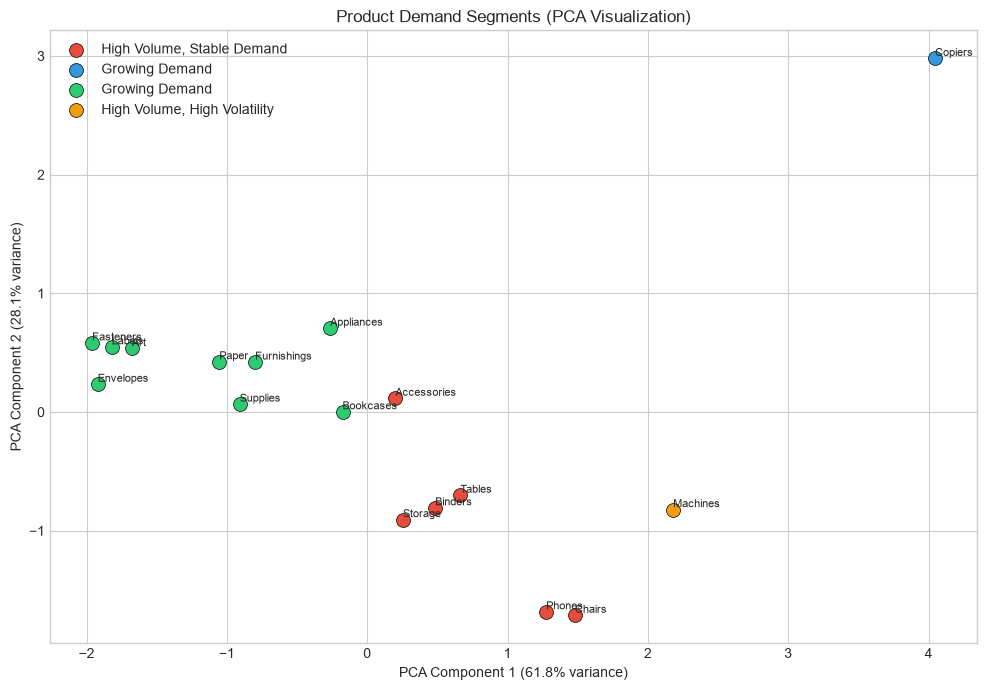

In [97]:
from sklearn.decomposition import PCA

# apply PCA
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_scaled)

cluster_df['PCA_1'] = pca_result[:, 0]
cluster_df['PCA_2'] = pca_result[:, 1]

# plot
plt.figure(figsize=(10, 7))
colors_cluster = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for cluster_id in sorted(cluster_df['Cluster'].unique()):
    mask = cluster_df['Cluster'] == cluster_id
    plt.scatter(cluster_df.loc[mask, 'PCA_1'], 
                cluster_df.loc[mask, 'PCA_2'], 
                c=colors_cluster[cluster_id], 
                label=labels[cluster_id],
                s=100, edgecolors='black', linewidth=0.5)
    
    # annotate each point with sub-category name
    for idx in cluster_df[mask].index:
        plt.annotate(idx, (cluster_df.loc[idx, 'PCA_1'], cluster_df.loc[idx, 'PCA_2']),
                     fontsize=8, ha='left', va='bottom')

plt.title('Product Demand Segments (PCA Visualization)')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend(loc='best')
plt.tight_layout()
plt.savefig('charts/demand_clusters_pca.png', dpi=150)
plt.show()

### Stocking strategy recommendations per cluster:

1. **High Volume, Stable Demand:** These products are reliable sellers. Maintain consistant inventory levels and use standard reorder points. These are your bread-and-butter items.

2. **High Volume, High Volatility:** These products sell a lot but unpredictably. Keep safety stock higher than usual and monitor sales trends closely. Use shorter reorder cycles.

3. **Growing Demand:** These products are on the rise. Gradually increase inventory levels each quarter. Monitor closely for when growth starts to plateau.

4. **Low Volume / Declining Demand:** Reduce inventory for these products. Consider discontinuing or running clearence sales. Don't tie up capital in slow-moving stock.

---

**End of Analysis Notebook** 

Tasks 7 (Streamlit Dashboard) and Task 8 (Executive Report) are in seperate files: `app.py` and `summary.docx` respectivley.